### Imports

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib
import sys
sys.path.append('/teamspace/studios/this_studio/Human-Activity-Recognition')
from src.lstm import build_lstm
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import os
import requests
import zipfile

I0000 00:00:1778736721.827231    6963 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778736722.401105    6963 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778736724.464341    6963 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Download Data

In [10]:
def download_data():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
    data_path = "../../data/UCI_HAR_Dataset.zip"

    if not os.path.exists('../../data'):
        os.makedirs('../../data')

    if not os.path.exists(data_path):
        response = requests.get(url)
        with open(data_path, 'wb') as f:
            f.write(response.content)

        with zipfile.ZipFile(data_path, 'r') as zip_ref:
            zip_ref.extractall('../../data')

download_data()

### Load & Preprocess Raw Sensor Data

In [2]:
sensor_names = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',     # Accelerometer measurements
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',  # Gyroscope measurements
    'total_acc_x', 'total_acc_y', 'total_acc_z'     # Raw accelerometer measurements before filtering (total acceleration)
]

def load_data(split_type):
    signals = []

    for sensor_name in sensor_names:
        file_path = os.path.join(f'../../data/UCI HAR Dataset/{split_type}/Inertial Signals/{sensor_name}_{split_type}.txt')
        signal = np.array(pd.read_csv(file_path, delim_whitespace=True, header=None).values)
        signals.append(signal)

    return np.array(signals).transpose(1, 2, 0)

def load_labels(split_type):
    file_path = os.path.join(f'../../data/UCI HAR Dataset/{split_type}/y_{split_type}.txt')
    # Convert 1 - 6 to 0 - 5
    return pd.read_csv(file_path, delim_whitespace=True, header=None).values.flatten() - 1


def normalize_data(X_train_raw, X_test_raw):
    n_samples_train, n_timesteps, n_features = X_train_raw.shape
    n_samples_test = X_test_raw.shape[0]

    # Reshape to (samples * timesteps, features) so scaler sees each feature
    X_train_flat = X_train_raw.reshape(-1, n_features)
    X_test_flat  = X_test_raw.reshape(-1, n_features)

    # Fit on training data only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_test_scaled  = scaler.transform(X_test_flat)

    # Reshape back to (samples, timesteps, features)
    X_train_norm = X_train_scaled.reshape(n_samples_train, n_timesteps, n_features)
    X_test_norm  = X_test_scaled.reshape(n_samples_test,  n_timesteps, n_features)

    return X_train_norm, X_test_norm, scaler

X_train_raw = load_data('train')
X_test_raw = load_data('test')
y_train = load_labels('train')
y_test = load_labels('test')
X_train_norm, X_test_norm, scaler = normalize_data(X_train_raw, X_test_raw)

# Save the scaler for future use
joblib.dump(scaler, '../../backend/har_scaler.joblib')

['../../backend/har_scaler.joblib']

### Build & Train The LSTM Model

In [3]:
model = build_lstm()
model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

history = model.fit(
    X_train_norm, y_train_categorical,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10)
    ]
)

test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_categorical, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
model.save('../../models/lstm.h5')

W0000 00:00:1778736744.590248    6963 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128, 128)       │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,110 (480.90 KB)

 Trainable params: 122,726 (479.40 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 164ms/step - accuracy: 0.6084 - loss: 1.0755 - val_accuracy: 0.7294 - val_loss: 0.9086
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 152ms/step - accuracy: 0.8024 - loss: 0.5275 - val_accuracy: 0.9164 - val_loss: 0.3368
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 152ms/step - accuracy: 0.8978 - loss: 0.3153 - val_accuracy: 0.9089 - val_loss: 0.2480
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 149ms/step - accuracy: 0.9189 - loss: 0.2402 - val_accuracy: 0.9320 - val_loss: 0.2487
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 149ms/step - accuracy: 0.9435 - loss: 0.1653 - val_accuracy: 0.9232 - val_loss: 0.2222
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 147ms/step - accuracy: 0.9458 - loss: 0.1636 - val_accuracy: 0.9021 - val_loss: 0.3424
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 149ms/step - accuracy: 0.9367 - loss: 0.2090 - val_accuracy: 0.9001 - val_loss: 0.2354
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step - accuracy: 0.9434 - loss: 0.1488 - val_accu

Test Accuracy: 0.9369


### Plots

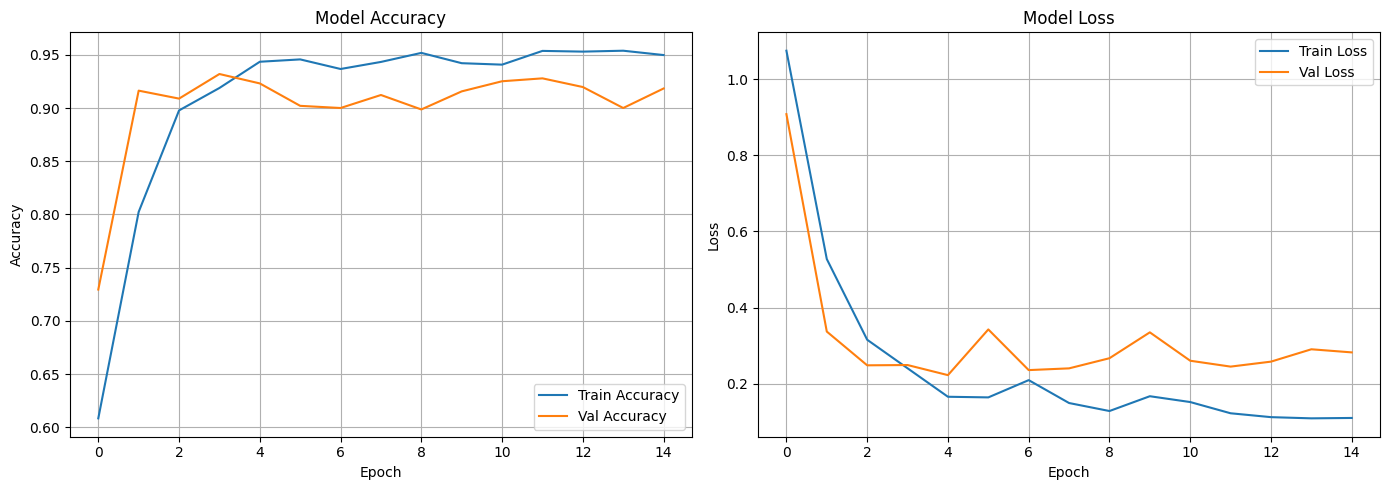

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()